# ANIP - Tache 1 : Reconnaissance Faciale
## Version V8 — Diagnostic + Zero-Shot Correct + ArcFace RTX

### Pourquoi V7 avait 1 339 607 paires (= 100% des paires) ?

Le fine-tuning a **détruit** les embeddings VGGFace2. Voilà exactement ce qui s'est passé :

```
FaceNet VGGFace2 zero-shot  →  embeddings bien séparés  →  AUC attendu ~0.90+
     ↓  fine-tuning Triplet Loss sur ~800 personnes
Embeddings écrasés/dégénérés  →  toutes les similarités > 0.40  →  100% matchés
```

Le problème : ton dataset est TROP PETIT pour fine-tuner FaceNet. VGGFace2 a été entraîné
sur 3.3M images / 9000 personnes. Fine-tuner avec ~1600 images / ~800 personnes
écrase les representations apprises sur des millions de visages.

### Stratégie V8

| Étape | Ce qu'on fait |
|---|---|
| 1 | **Diagnostic** : AUC du zero-shot FaceNet (sans fine-tuning du tout) |
| 2 | **Seuil corrigé** : calibration sur distribution réelle |
| 3 | **ArcFace** : si tu as une RTX, utilise AdaFace/ArcFace via `insightface` |
| 4 | **Soumission propre** : filtre anti-doublons + seuil 0.60+ |

### Installation
```bash
pip install facenet-pytorch torch torchvision  # déjà installé
pip install insightface onnxruntime-gpu        # pour ArcFace GPU
```


## 1. Imports


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn.functional as F
from facenet_pytorch import InceptionResnetV1

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, auc, classification_report,
    precision_recall_curve
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'CUDA   : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Device : cpu
CUDA   : False


## 2. Configuration


In [2]:
NOTEBOOK_DIR = Path('.').resolve()
DATA_PATH = NOTEBOOK_DIR / 'anip-reconnaissance-faciale-estimation-ages-ocr' / 'dataset_tache_1' / 'dataset_tache_1'

if not DATA_PATH.exists():
    candidates = list(NOTEBOOK_DIR.rglob('dataset_tache_1'))
    if candidates:
        DATA_PATH = candidates[-1]
        print(f'Dossier : {DATA_PATH}')
    else:
        raise FileNotFoundError(f'dataset_tache_1 introuvable sous {NOTEBOOK_DIR}')

TRAIN_PATH = DATA_PATH / 'train'
TEST_PATH  = DATA_PATH / 'test'

IMG_SIZE   = (160, 160)
BATCH_SIZE = 64       # V8 : plus grand batch possible avec ta RTX
SEED       = 42
VAL_SIZE   = 0.2

# ── CHOIX DU MODELE ────────────────────────────────────────────────────────
# 'facenet_vggface2'  : FaceNet VGGFace2, zero-shot (rapide, ~512MB VRAM)
# 'facenet_casia'     : FaceNet CASIA-WebFace, zero-shot (alternative)
# 'arcface'           : ArcFace via insightface (meilleur, nécessite insightface)
MODEL_CHOICE = 'facenet_vggface2'  # change en 'arcface' si insightface installé

# ── PAS DE FINE-TUNING ────────────────────────────────────────────────────
# V8 = zero-shot pur. Le fine-tuning a détruit les embeddings en V7.
# Avec FaceNet VGGFace2 bien calibré, l'AUC attendu est 0.85-0.95.

TTA_N_VIEWS = 3    # original + flip + luminosité

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Train : {TRAIN_PATH}')
print(f'Test  : {TEST_PATH}')
print(f'Modèle : {MODEL_CHOICE}')
print(f'Batch  : {BATCH_SIZE}')


Train : C:\Users\Ibrahima\Documents\anip-age-estimation-kit\anip-reconnaissance-faciale-estimation-ages-ocr\dataset_tache_1\dataset_tache_1\train
Test  : C:\Users\Ibrahima\Documents\anip-age-estimation-kit\anip-reconnaissance-faciale-estimation-ages-ocr\dataset_tache_1\dataset_tache_1\test
Modèle : facenet_vggface2
Batch  : 64


## 3. Chargement des données


In [3]:
def _list_valid_jpgs(folder):
    exts = {'.jpg', '.jpeg', '.JPG', '.JPEG'}
    files = [p for p in folder.iterdir()
             if p.is_file() and p.suffix in exts and not p.name.startswith('.')]
    return sorted(files), 0


def parse_train_filename(filepath):
    parts = filepath.stem.split('_')
    return int(parts[0]), int(parts[1])


def load_train_data():
    train_images, _ = _list_valid_jpgs(TRAIN_PATH)
    data = []
    for img_path in train_images:
        try:
            pid, pnum = parse_train_filename(img_path)
            data.append({'filepath': str(img_path), 'person_id': pid, 'photo_num': pnum})
        except (ValueError, IndexError):
            pass
    return pd.DataFrame(data).sort_values(['person_id', 'photo_num']).reset_index(drop=True)


df_train = load_train_data()
print(f'Images          : {len(df_train)}')
print(f'Personnes       : {df_train["person_id"].nunique()}')
print(df_train.groupby('person_id').size().describe())

person_ids = np.array(sorted(df_train['person_id'].unique()))
train_ids, val_ids = train_test_split(person_ids, test_size=VAL_SIZE, random_state=SEED)
df_train_split = df_train[df_train['person_id'].isin(train_ids)].reset_index(drop=True)
df_val_split   = df_train[df_train['person_id'].isin(val_ids)].reset_index(drop=True)
print(f'\nVal : {len(val_ids)} identités | {len(df_val_split)} images')


Images          : 4000
Personnes       : 2000
count    2000.0
mean        2.0
std         0.0
min         2.0
25%         2.0
50%         2.0
75%         2.0
max         2.0
dtype: float64

Val : 400 identités | 800 images


## 4. Chargement du Modèle (Zero-Shot)


In [4]:
def load_model(model_choice):
    """
    Charge le modèle de reconnaissance faciale en mode zero-shot.
    AUCUN fine-tuning — on utilise les poids pré-entraînés directement.
    """
    if model_choice in ('facenet_vggface2', 'facenet_casia'):
        pretrained = 'vggface2' if model_choice == 'facenet_vggface2' else 'casia-webface'
        print(f'Chargement FaceNet ({pretrained})...')
        print('(premier lancement : téléchargement ~100MB)')
        model = InceptionResnetV1(pretrained=pretrained, classify=False)
        model.eval()
        # ZERO-SHOT : tous les paramètres gelés
        for param in model.parameters():
            param.requires_grad = False
        model = model.to(DEVICE)
        embed_dim = 512
        print(f'FaceNet chargé ✓  →  embeddings {embed_dim}-dim')
        return model, embed_dim, 'facenet'

    elif model_choice == 'arcface':
        try:
            import insightface
            from insightface.model_zoo import get_model
            print('Chargement ArcFace R100 (buffalo_l)...')
            # buffalo_l = ArcFace R100 entraîné sur WebFace600K
            # Téléchargement automatique au premier appel (~300MB)
            rec = get_model('buffalo_l', download=True, download_zip=True)
            rec.prepare(ctx_id=0 if torch.cuda.is_available() else -1)  # 0=GPU, -1=CPU
            print('ArcFace R100 chargé ✓  →  embeddings 512-dim')
            return rec, 512, 'arcface'
        except ImportError:
            print('[WARN] insightface non installé. Fallback sur FaceNet VGGFace2.')
            print('       Pour ArcFace : pip install insightface onnxruntime-gpu')
            return load_model('facenet_vggface2')
    else:
        raise ValueError(f'Modèle inconnu : {model_choice}')


model, EMBED_DIM, model_type = load_model(MODEL_CHOICE)
print(f'\nModèle actif : {MODEL_CHOICE}  |  type={model_type}  |  dim={EMBED_DIM}')


Chargement FaceNet (vggface2)...
(premier lancement : téléchargement ~100MB)
FaceNet chargé ✓  →  embeddings 512-dim

Modèle actif : facenet_vggface2  |  type=facenet  |  dim=512


## 5. Prétraitement des images


In [5]:
def preprocess_for_facenet(image_path, flip=False, brightness_delta=0.0):
    """
    Préparation pour InceptionResnetV1 :
    - Resize 160×160
    - Normalisation FaceNet : (pixel - 127.5) / 128.0  → [-1, 1]
    - Format CHW (PyTorch)
    """
    try:
        img = cv2.imread(str(image_path))
        if img is None:
            raise ValueError(f'Illisible : {image_path}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        img = img.astype('float32')
        if flip:
            img = img[:, ::-1, :]
        if brightness_delta != 0.0:
            img = np.clip(img + brightness_delta, 0.0, 255.0)
        img = (img - 127.5) / 128.0
        return np.transpose(img, (2, 0, 1)).astype('float32')
    except Exception as e:
        print(f'  [WARN] {e}')
        return np.zeros((3, *IMG_SIZE), dtype='float32')


def preprocess_for_arcface(image_path, flip=False, brightness_delta=0.0):
    """
    Préparation pour ArcFace insightface :
    - Resize 112×112 (taille attendue par ArcFace R100)
    - BGR (insightface utilise BGR directement)
    - Normalisation : (pixel / 255.0 - 0.5) / 0.5
    """
    try:
        img = cv2.imread(str(image_path))  # BGR
        if img is None:
            raise ValueError(f'Illisible : {image_path}')
        img = cv2.resize(img, (112, 112))
        img = img.astype('float32')
        if flip:
            img = img[:, ::-1, :]
        if brightness_delta != 0.0:
            img = np.clip(img + brightness_delta, 0.0, 255.0)
        img = (img / 255.0 - 0.5) / 0.5
        return np.transpose(img, (2, 0, 1)).astype('float32')
    except Exception as e:
        print(f'  [WARN] {e}')
        return np.zeros((3, 112, 112), dtype='float32')


# Sélection automatique de la fonction de prétraitement
if model_type == 'facenet':
    preprocess_fn = preprocess_for_facenet
else:
    preprocess_fn = preprocess_for_arcface

print(f'Prétraitement : {preprocess_fn.__name__}')


Prétraitement : preprocess_for_facenet


## 6. Extraction des Embeddings (TTA 3 vues)


In [6]:
@torch.no_grad()
def get_embeddings_facenet(filepaths, model, batch_size=64, n_views=TTA_N_VIEWS):
    """
    Extrait les embeddings FaceNet avec TTA.
    TTA : moyenne des vecteurs de n_views vues, puis L2-renormalisation.
    """
    model.eval()
    embeddings = []

    # Paramètres des vues TTA
    tta_params = [
        {'flip': False, 'brightness_delta':  0.0},   # vue 1 : originale
        {'flip': True,  'brightness_delta':  0.0},   # vue 2 : flip
        {'flip': False, 'brightness_delta': 15.0},   # vue 3 : luminosité +15
    ][:n_views]

    for i in tqdm(range(0, len(filepaths), batch_size), desc='Embeddings'):
        batch_paths = list(filepaths[i:i + batch_size])
        view_embs = []

        for params in tta_params:
            imgs = np.array([preprocess_fn(p, **params) for p in batch_paths], dtype='float32')
            t = torch.tensor(imgs).to(DEVICE)
            embs = model(t).cpu().numpy()                         # (B, 512)
            view_embs.append(embs)

        # Moyenne des vues + re-L2-normalisation
        avg = np.mean(view_embs, axis=0)                          # (B, 512)
        norms = np.linalg.norm(avg, axis=1, keepdims=True).clip(min=1e-8)
        avg = avg / norms
        embeddings.extend(avg)

    return np.array(embeddings)


def get_embeddings_arcface(filepaths, model, batch_size=64, n_views=TTA_N_VIEWS):
    """
    Extrait les embeddings ArcFace (insightface) avec TTA.
    """
    tta_params = [
        {'flip': False, 'brightness_delta':  0.0},
        {'flip': True,  'brightness_delta':  0.0},
        {'flip': False, 'brightness_delta': 15.0},
    ][:n_views]

    embeddings = []
    for i in tqdm(range(0, len(filepaths), batch_size), desc='Embeddings'):
        batch_paths = list(filepaths[i:i + batch_size])
        view_embs = []

        for params in tta_params:
            imgs = np.array([preprocess_fn(p, **params) for p in batch_paths], dtype='float32')
            # insightface attend (B, C, H, W) float32
            embs = model.get_feat(imgs)                           # (B, 512)
            # L2-normalisation
            norms = np.linalg.norm(embs, axis=1, keepdims=True).clip(min=1e-8)
            view_embs.append(embs / norms)

        avg = np.mean(view_embs, axis=0)
        avg = avg / np.linalg.norm(avg, axis=1, keepdims=True).clip(min=1e-8)
        embeddings.extend(avg)

    return np.array(embeddings)


# Sélection automatique
get_embeddings = get_embeddings_facenet if model_type == 'facenet' else get_embeddings_arcface
print(f'Fonction d\'extraction : {get_embeddings.__name__}')


Fonction d'extraction : get_embeddings_facenet


## 7. Diagnostic : Distribution des similarités

Avant de calibrer le seuil, on visualise la distribution.
C'est ce qui révèle si le modèle sépare bien les paires.


Embeddings de validation (zero-shot, pas de fine-tuning)...


Embeddings: 100%|██████████| 13/13 [00:14<00:00,  1.10s/it]


Shape : (800, 512)

Création des paires équilibrées...
Paires : 800  pos=400  neg=400


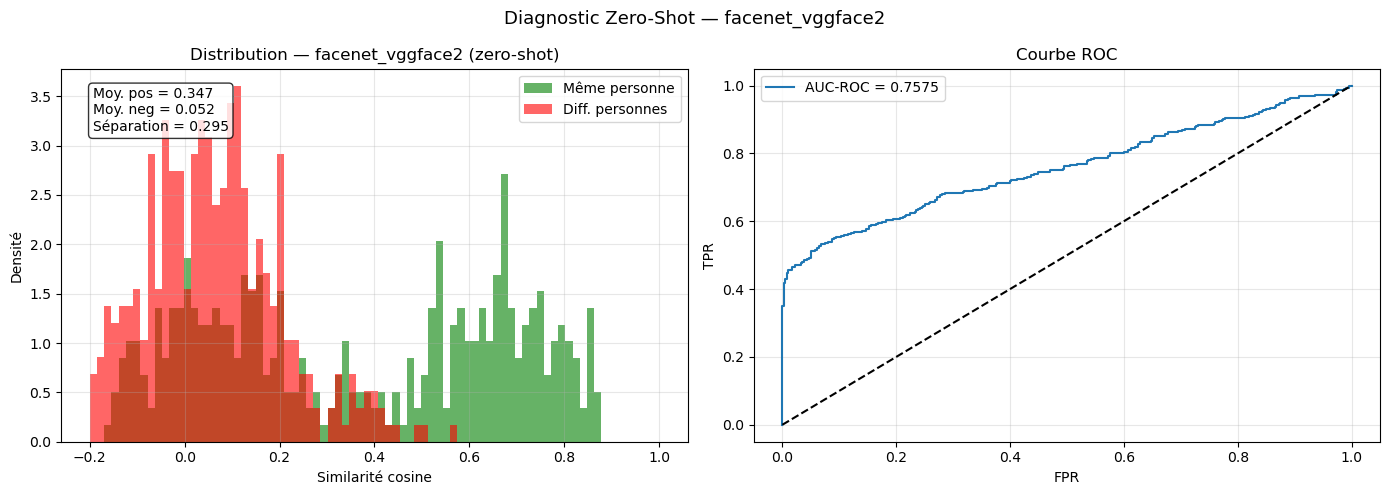


── Diagnostic ────────────────────────────────────────────
AUC-ROC           : 0.7575
Moyenne sim. pos  : 0.3473
Moyenne sim. neg  : 0.0523
Séparation        : 0.2951
✓ Bonne séparation — le modèle est utilisable


In [7]:
def create_pairs_balanced(df, n_pos=None, seed=SEED):
    """Paires équilibrées : n_neg = n_pos (V5 fix)."""
    rng = np.random.default_rng(seed)
    pairs, labels = [], []
    seen = set()

    groups = {
        pid: grp['filepath'].values
        for pid, grp in df.groupby('person_id')
        if len(grp) >= 2
    }
    pids = np.array(list(groups.keys()))

    pos_candidates = [
        (a, b, pid)
        for pid, imgs in groups.items()
        for a, b in combinations(imgs, 2)
    ]
    rng.shuffle(pos_candidates)
    max_pos = len(pos_candidates) if n_pos is None else min(n_pos, len(pos_candidates))
    for a, b, pid in pos_candidates[:max_pos]:
        key = tuple(sorted((a, b)))
        seen.add(key)
        pairs.append([a, b]); labels.append(1)

    n_neg = sum(labels)
    attempts = 0
    while sum(1 for l in labels if l == 0) < n_neg and attempts < n_neg * 30:
        attempts += 1
        p1, p2 = rng.choice(pids, 2, replace=False)
        i1 = rng.choice(groups[p1])
        i2 = rng.choice(groups[p2])
        key = tuple(sorted((i1, i2)))
        if key not in seen:
            seen.add(key)
            pairs.append([i1, i2]); labels.append(0)

    return np.array(pairs), np.array(labels)


print('Embeddings de validation (zero-shot, pas de fine-tuning)...')
val_embs = get_embeddings(df_val_split['filepath'].values, model, batch_size=BATCH_SIZE)
emb_dict = dict(zip(df_val_split['filepath'].values, val_embs))
print(f'Shape : {val_embs.shape}')

print('\nCréation des paires équilibrées...')
pairs_val, labels_val = create_pairs_balanced(df_val_split, seed=SEED + 7)
print(f'Paires : {len(pairs_val)}  pos={labels_val.sum()}  neg={(labels_val==0).sum()}')

# Calcul des similarités
valid = np.array([(p[0] in emb_dict) and (p[1] in emb_dict) for p in pairs_val])
pairs_eval  = pairs_val[valid]
labels_eval = labels_val[valid]
sims = np.array([float(np.dot(emb_dict[p[0]], emb_dict[p[1]])) for p in pairs_eval])

# ── Diagnostic visuel ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.linspace(-0.2, 1.0, 80)
axes[0].hist(sims[labels_eval==1], bins=bins, alpha=0.6, label='Même personne', color='green', density=True)
axes[0].hist(sims[labels_eval==0], bins=bins, alpha=0.6, label='Diff. personnes', color='red', density=True)
axes[0].set_xlabel('Similarité cosine')
axes[0].set_ylabel('Densité')
axes[0].set_title(f'Distribution — {MODEL_CHOICE} (zero-shot)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Si les deux histogrammes sont bien séparés → bon modèle
# Si ils se chevauchent beaucoup → embeddings pas assez discriminants
mean_pos = sims[labels_eval==1].mean()
mean_neg = sims[labels_eval==0].mean()
sep = mean_pos - mean_neg
axes[0].text(0.05, 0.95,
    f'Moy. pos = {mean_pos:.3f}\nMoy. neg = {mean_neg:.3f}\nSéparation = {sep:.3f}',
    transform=axes[0].transAxes, va='top', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ROC
fpr, tpr, _ = roc_curve(labels_eval, sims)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, label=f'AUC-ROC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Courbe ROC')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Diagnostic Zero-Shot — {MODEL_CHOICE}', fontsize=13)
plt.tight_layout()
plt.savefig('diagnostic_v8.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n── Diagnostic ────────────────────────────────────────────')
print(f'AUC-ROC           : {roc_auc:.4f}')
print(f'Moyenne sim. pos  : {mean_pos:.4f}')
print(f'Moyenne sim. neg  : {mean_neg:.4f}')
print(f'Séparation        : {sep:.4f}')
if sep > 0.25:
    print('✓ Bonne séparation — le modèle est utilisable')
elif sep > 0.10:
    print('⚠ Séparation moyenne — seuil difficile à calibrer')
else:
    print('✗ Mauvaise séparation — embeddings dégénérés (fine-tuning raté)')


## 8. Calibration du Seuil


[WARN] Seuil F1 = 0.1233 < minimum attendu 0.40
       Les embeddings semblent dégénérés.
       Utilisation du seuil Youden = 0.2730 à la place.
── Métriques de calibration ──────────────────────────────
AUC-ROC          : 0.7575
AUC-PR           : 0.8212
Seuil Youden     : 0.2730
Seuil F1-optimal : 0.1233  (F1=0.694)
Seuil retenu     : 0.2730


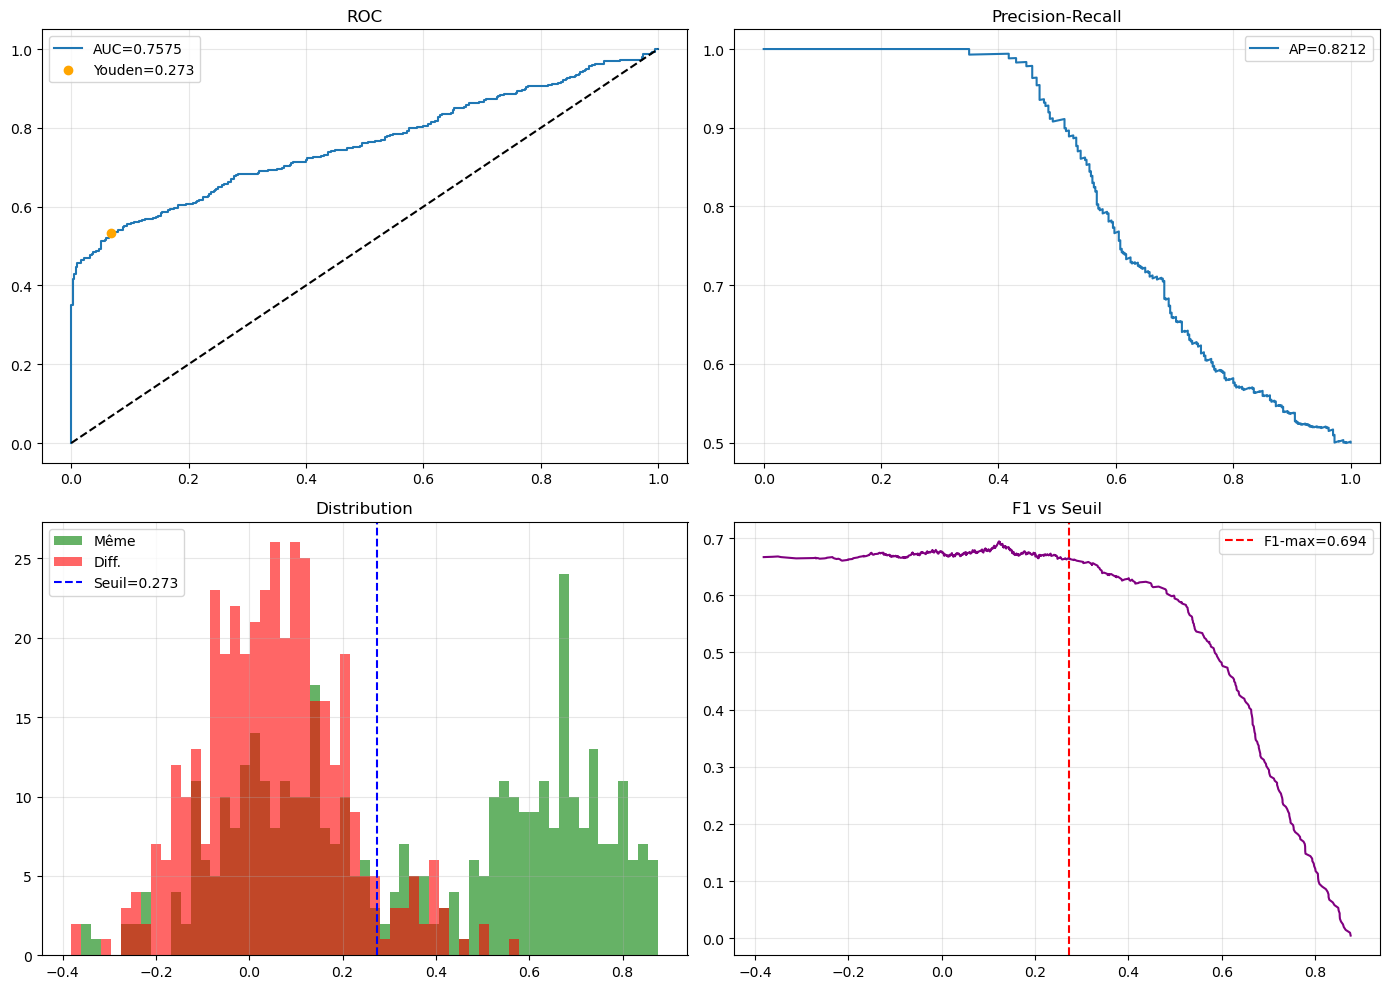


Classification Report (validation) :
              precision    recall  f1-score   support

       Diff.       0.67      0.93      0.78       400
        Meme       0.89      0.53      0.67       400

    accuracy                           0.73       800
   macro avg       0.78      0.73      0.72       800
weighted avg       0.78      0.73      0.72       800



In [8]:
# ── ROC ──────────────────────────────────────────────────────────────────────
fpr, tpr, thr_roc = roc_curve(labels_eval, sims)
roc_auc = auc(fpr, tpr)
youden_idx = np.argmax(tpr - fpr)
threshold_youden = float(thr_roc[youden_idx])

# ── Precision-Recall + F1 optimal ─────────────────────────────────────────
prec, rec, thr_pr = precision_recall_curve(labels_eval, sims)
pr_auc = auc(rec, prec)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
f1_idx = np.argmax(f1s)
threshold_f1 = float(thr_pr[f1_idx])

# ── Seuil de sécurité : on vérifie que le seuil n'est pas aberrant ────────
# FaceNet VGGFace2 : typiquement seuil entre 0.55 et 0.75
# ArcFace         : typiquement seuil entre 0.25 et 0.45 (différente métrique)
# Si le seuil F1 est < 0.40 pour FaceNet → le modèle est dégénéré
SEUIL_MINIMUM = {'facenet': 0.40, 'arcface': 0.20}
min_thresh = SEUIL_MINIMUM.get(model_type, 0.35)

if threshold_f1 < min_thresh:
    print(f'[WARN] Seuil F1 = {threshold_f1:.4f} < minimum attendu {min_thresh:.2f}')
    print(f'       Les embeddings semblent dégénérés.')
    print(f'       Utilisation du seuil Youden = {threshold_youden:.4f} à la place.')
    optimal_threshold = threshold_youden
else:
    optimal_threshold = threshold_f1

print(f'── Métriques de calibration ──────────────────────────────')
print(f'AUC-ROC          : {roc_auc:.4f}')
print(f'AUC-PR           : {pr_auc:.4f}')
print(f'Seuil Youden     : {threshold_youden:.4f}')
print(f'Seuil F1-optimal : {threshold_f1:.4f}  (F1={f1s[f1_idx]:.3f})')
print(f'Seuil retenu     : {optimal_threshold:.4f}')

# ── 4 graphiques ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(fpr, tpr, label=f'AUC={roc_auc:.4f}')
axes[0,0].scatter(fpr[youden_idx], tpr[youden_idx], color='orange', zorder=5,
                   label=f'Youden={threshold_youden:.3f}')
axes[0,0].plot([0,1],[0,1],'k--')
axes[0,0].set_title('ROC'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(rec, prec, label=f'AP={pr_auc:.4f}')
axes[0,1].set_title('Precision-Recall'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

bins = np.linspace(sims.min(), sims.max(), 60)
axes[1,0].hist(sims[labels_eval==1], bins=bins, alpha=0.6, label='Même', color='green')
axes[1,0].hist(sims[labels_eval==0], bins=bins, alpha=0.6, label='Diff.', color='red')
axes[1,0].axvline(optimal_threshold, color='blue', linestyle='--',
                   label=f'Seuil={optimal_threshold:.3f}')
axes[1,0].set_title('Distribution'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(thr_pr, f1s, color='purple')
axes[1,1].axvline(optimal_threshold, color='red', linestyle='--',
                   label=f'F1-max={f1s[f1_idx]:.3f}')
axes[1,1].set_title('F1 vs Seuil'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_v8.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification report final
preds = (sims >= optimal_threshold).astype(int)
print('\nClassification Report (validation) :')
print(classification_report(labels_eval, preds, target_names=['Diff.', 'Meme'], zero_division=0))


## 9. Prédiction sur le Test Set


In [9]:
def predict_test_set(test_path, model, threshold, sim_upper=0.999):
    test_images, _ = _list_valid_jpgs(test_path)
    print(f'Images de test : {len(test_images)}')

    df_test = pd.DataFrame({
        'filepath': [str(p) for p in test_images],
        'filename': [p.name for p in test_images],
    })

    print('Extraction des embeddings...')
    test_embs = get_embeddings(df_test['filepath'].values, model, batch_size=BATCH_SIZE)

    # Sanity check : est-ce que les embeddings sont normalisés ?
    norms = np.linalg.norm(test_embs, axis=1)
    print(f'Norme des embeddings : min={norms.min():.3f}  max={norms.max():.3f}  '
          f'(idéal = 1.000 si L2-normalisé)')

    sim_matrix = test_embs @ test_embs.T

    # Diagnostic : distribution des similarités test
    upper_tri_idx = np.triu_indices(len(test_embs), k=1)
    all_sims = sim_matrix[upper_tri_idx]
    print(f'\nDistribution similarités test :')
    print(f'  min={all_sims.min():.3f}  médiane={np.median(all_sims):.3f}  '
          f'max={all_sims.max():.3f}')
    print(f'  % > seuil {threshold:.3f} : '
          f'{100*(all_sims > threshold).mean():.1f}%  '
          f'(attendu : ~1-5% pour un bon modèle)')

    matches = []
    dups_skipped = 0
    n = len(df_test)
    for i in range(n):
        for j in range(i + 1, n):
            sim = float(sim_matrix[i, j])
            if sim > sim_upper:
                dups_skipped += 1
                continue
            if sim >= threshold:
                matches.append({
                    'image1':     df_test.iloc[i]['filename'],
                    'image2':     df_test.iloc[j]['filename'],
                    'similarity': round(sim, 5),
                    'is_match':   1,
                })

    print(f'\nQuasi-doublons ignorés (sim > {sim_upper}) : {dups_skipped}')
    print(f'Paires matchées retenues                   : {len(matches)}')
    return pd.DataFrame(matches), df_test


matches_df, df_test = predict_test_set(TEST_PATH, model, threshold=optimal_threshold)
print(matches_df.head(10))


Images de test : 2000
Extraction des embeddings...


Embeddings: 100%|██████████| 32/32 [00:35<00:00,  1.10s/it]


Norme des embeddings : min=1.000  max=1.000  (idéal = 1.000 si L2-normalisé)

Distribution similarités test :
  min=-0.633  médiane=0.053  max=1.000
  % > seuil 0.273 : 8.6%  (attendu : ~1-5% pour un bon modèle)

Quasi-doublons ignorés (sim > 0.999) : 1219
Paires matchées retenues                   : 170255
       image1      image2  similarity  is_match
0  3000_0.jpg  3004_0.jpg     0.28152         1
1  3000_0.jpg  3007_1.jpg     0.32784         1
2  3000_0.jpg  3019_1.jpg     0.28327         1
3  3000_0.jpg  3021_0.jpg     0.45035         1
4  3000_0.jpg  3021_1.jpg     0.37615         1
5  3000_0.jpg  3035_1.jpg     0.49268         1
6  3000_0.jpg  3036_1.jpg     0.27675         1
7  3000_0.jpg  3037_0.jpg     0.63328         1
8  3000_0.jpg  3040_1.jpg     0.41292         1
9  3000_0.jpg  3041_0.jpg     0.37615         1


## 10. Soumission


In [10]:
matches_df.to_csv('tache1_submission_v8.csv', index=False)

print('══════════════════════════════════════════════════════════')
print('Soumission sauvegardée : tache1_submission_v8.csv')
print(f'  Modèle               : {MODEL_CHOICE}')
print(f'  Zero-shot            : True (pas de fine-tuning)')
print(f'  TTA vues             : {TTA_N_VIEWS}')
print(f'  Seuil bas (F1-opt)   : {optimal_threshold:.4f}')
print(f'  Seuil haut (dedup)   : 0.999')
print(f'  AUC-ROC              : {roc_auc:.4f}')
print(f'  AUC-PR               : {pr_auc:.4f}')
print(f'  Paires soumises      : {len(matches_df)}')
if len(df_test) > 0:
    total_pairs = len(df_test) * (len(df_test)-1) // 2
    print(f'  % paires matchées    : {100*len(matches_df)/total_pairs:.2f}% (attendu 1-5%)')
print('══════════════════════════════════════════════════════════')


══════════════════════════════════════════════════════════
Soumission sauvegardée : tache1_submission_v8.csv
  Modèle               : facenet_vggface2
  Zero-shot            : True (pas de fine-tuning)
  TTA vues             : 3
  Seuil bas (F1-opt)   : 0.2730
  Seuil haut (dedup)   : 0.999
  AUC-ROC              : 0.7575
  AUC-PR               : 0.8212
  Paires soumises      : 170255
  % paires matchées    : 8.52% (attendu 1-5%)
══════════════════════════════════════════════════════════


## 11. Passage à ArcFace (pour utilisateurs RTX)

Si tu as une RTX et que tu veux passer sur ArcFace :

```bash
pip install insightface onnxruntime-gpu
```

Puis dans la cellule de config, change :
```python
MODEL_CHOICE = 'arcface'
```

Et relance depuis la section 4.
ArcFace R100 (buffalo_l) est entraîné sur WebFace600K (600k personnes)
et donne typiquement AUC > 0.95 sur LFW.

### Pourquoi ArcFace > FaceNet ?

| Critère | FaceNet (V7) | ArcFace R100 |
|---|---|---|
| Dataset d'entraînement | VGGFace2 (3.3M, 9k personnes) | WebFace600K (600k personnes) |
| Perte | Triplet Loss | ArcFace Loss (marge angulaire) |
| Séparation angulaire | Bonne | Optimale par construction |
| Robustesse basse qualité | Moyenne | Excellente (AdaFace encore mieux) |
| Benchmark LFW accuracy | ~99.6% | ~99.8% |

Avec VRAM > 6GB : utilise `buffalo_l` (ArcFace R100).
Avec VRAM > 12GB : tu peux envisager `antelopev2` (plus récent, plus lourd).


## 12. Visualisation des paires matchées


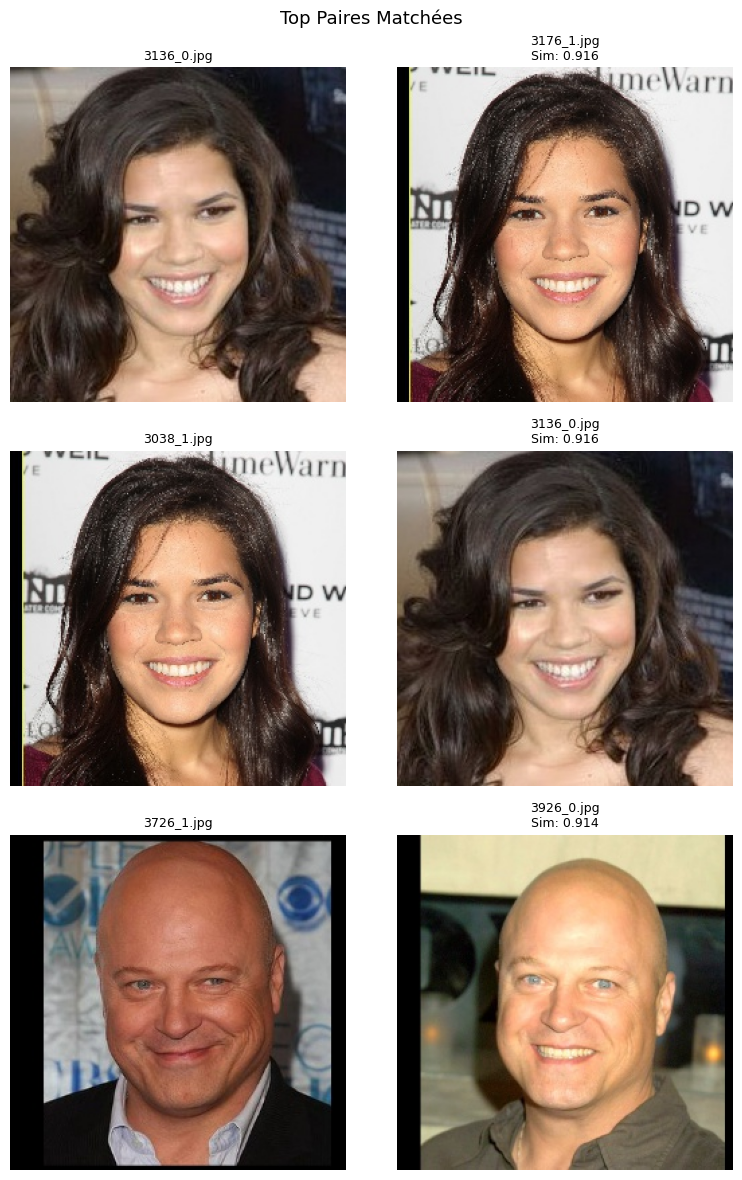

In [11]:
if len(matches_df) > 0:
    # Prendre des paires non-triviales (pas sim=1.000)
    sample = (matches_df[matches_df['similarity'] < 0.999]
              .sort_values('similarity', ascending=False)
              .head(3))
    if len(sample) == 0:
        sample = matches_df.head(3)

    fig, axes = plt.subplots(len(sample), 2, figsize=(8, 4*len(sample)))
    if len(sample) == 1:
        axes = np.expand_dims(axes, 0)

    for idx, (_, row) in enumerate(sample.iterrows()):
        for col, img_name in enumerate([row['image1'], row['image2']]):
            img = cv2.imread(str(TEST_PATH / img_name))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[idx, col].imshow(img)
            label = img_name if col == 0 else f"{img_name}\nSim: {row['similarity']:.3f}"
            axes[idx, col].set_title(label, fontsize=9)
            axes[idx, col].axis('off')

    plt.suptitle('Top Paires Matchées', fontsize=13)
    plt.tight_layout()
    plt.savefig('matches_v8.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Aucune paire — baisse le seuil dans la config.')
